In [3]:
import pandas as pd
from pathlib import Path
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score


In [4]:
def find_project_directory():
    """
    Détermine le repertoire du projet
    """
    # Récupérer le chemin d'accès du répertoire courant
    current_dir = os.getcwd()
    # Accéder au répertoire parent en utilisant os.pardir : on accède alors au repertoire scr
    parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
    
    return parent_dir

def nulls_summary_table(df):
    """
    Returns a summary table showing null value counts and percentage
    
    Parameters:
    df (DataFrame): Dataframe to check
    
    Returns:
    null_values (DataFrame)
    """
    null_values = pd.DataFrame(df.isnull().sum())
    null_values[1] = null_values[0]/len(df)
    null_values.columns = ['null_count','null_pct']
    return null_values
project_directory= find_project_directory()

def mode_imputation(df,column):
    """ Remplacer les valeurs manquantes par le mode de la colonne (valeurs catégorielles).
    df:Dataframe
    columns: colonne a traiter
    """
    # Calculate most frequent value (mode)for column
    mode_column = df[column].mode()[0]
    # impute mode value in column
    df[column] = df[column].fillna(mode_column)
    print (f"Les valeurs manquantes de la colonne {column} ont ete remplacees par le mode")
    return df[column]

In [5]:
#imports des modules

import sys
sys.path.append(project_directory)

from src.data.load_data import load_csv_data
from src.data.clean_data import mean_imputation,mode_imputation,drop_duplicates,tri_colonnes
from src.data.split_data import split_data
from src.data.preprocess_data import *
from src.data.eda import visualisation_distrib_variable
#from src.data.eda import nulls_summary_table


In [6]:
df=load_csv_data("bankchurn.csv")

Data loaded successfully from /media/frederic/Echanges_Linux_Windows/GitHUb/Technical_Day_DS_2024/data_to_use/raw/bankchurn.csv


In [7]:
print(df.shape)
display(df.info())
display(df.describe(include = "all"))

(9999, 12)
<class 'pandas.core.frame.DataFrame'>
Index: 9999 entries, 15647311 to 15628319
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Surname          9787 non-null   object 
 1   CreditScore      9999 non-null   int64  
 2   Geography        9999 non-null   object 
 3   Gender           9999 non-null   object 
 4   Age              9977 non-null   object 
 5   Tenure           9509 non-null   float64
 6   Balance          9999 non-null   float64
 7   NumOfProducts    9999 non-null   int64  
 8   HasCrCard        9999 non-null   int64  
 9   IsActiveMember   9999 non-null   int64  
 10  EstimatedSalary  9999 non-null   float64
 11  Exited           9999 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 1015.5+ KB


None

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,9787,9999.000000,9999,9999,9977,9509.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.00000
unique,2919,NaN,3,2,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Smith,NaN,France,Male,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,32,NaN,5013,5457,478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,650.531953,NaN,NaN,NaN,4.756126,76493.538642,1.530253,0.705471,0.515052,100090.114004,0.20362
std,NaN,96.657618,NaN,NaN,NaN,2.729100,62395.836502,0.581659,0.455854,0.499798,57513.367468,0.40271
min,NaN,350.000000,NaN,NaN,NaN,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.00000
25%,NaN,584.000000,NaN,NaN,NaN,2.000000,0.000000,1.000000,0.000000,0.000000,50992.930000,0.00000
50%,NaN,652.000000,NaN,NaN,NaN,5.000000,97208.460000,1.000000,1.000000,1.000000,100187.430000,0.00000
75%,NaN,718.000000,NaN,NaN,NaN,7.000000,127646.040000,2.000000,1.000000,1.000000,149392.065000,0.00000


In [ ]:
#Variable surname to drop!

In [8]:
df["Age"] = df["Age"].astype(float)

ValueError: could not convert string to float: '8?'

In [9]:
df["Age"] = df["Age"].str.replace("?", "0").astype(float)

Tenure est un statut académique existant dans certains pays. Un poste avec tenure est une nomination académique indéfinie qui ne peut être terminée qu'avec une raison valable ou dans des circonstances extraordinaires, comme une urgence financière ou l'arrêt d'un programme. La tenure est un moyen de défendre le principe de la liberté académique, qui soutient qu'il est bénéfique pour la société à long terme si les universitaires sont libres de détenir et d'examiner une variété de points de vue.

In [10]:
# Missing values

display(df.isna().sum())
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Tenure"] = df["Tenure"].fillna(df["Tenure"].median())

Surname            212
CreditScore          0
Geography            0
Gender               0
Age                 22
Tenure             490
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

In [105]:
nulls_summary_table(df)

,null_count,null_pct
Surname,212,0.021202
CreditScore,0,0.000000
Geography,0,0.000000
Gender,0,0.000000
Age,22,0.002200
Tenure,490,0.049005
Balance,0,0.000000
NumOfProducts,0,0.000000
HasCrCard,0,0.000000
IsActiveMember,0,0.000000


In [11]:
# Duplicates

df.duplicated().sum()

0

In [149]:
df.value_counts('Exited')

Exited
0    7963
1    2036
Name: count, dtype: int64

### Distribution d'une variable catégorielle avec un count_plot

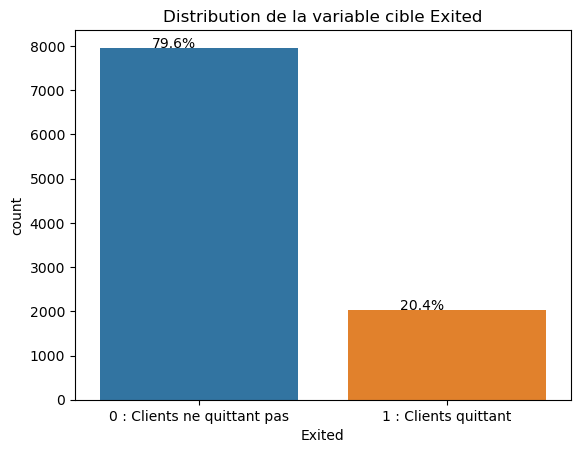

In [12]:
ax1 = sns.countplot(x = "Exited", data = df)

total = len(df["Exited"])
for p in ax1.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 0.1
    ax1.text(x, y, percentage, ha = 'center')

plt.title("Distribution de la variable cible Exited", fontsize = 12)
plt.xticks(ticks = range(2), labels = ["0 : Clients ne quittant pas", "1 : Clients quittant"]);

<Axes: xlabel='Tenure', ylabel='count'>

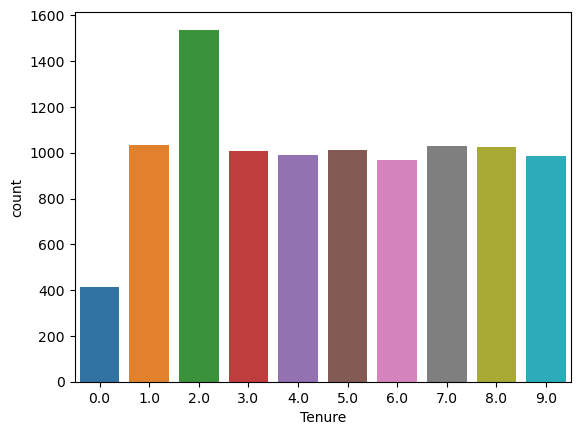

In [150]:
sns.countplot(x='Tenure', data=df)

<Axes: xlabel='Geography', ylabel='count'>

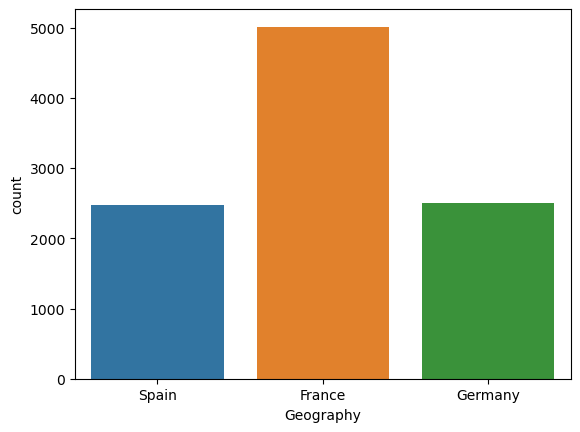

In [151]:
sns.countplot(x='Geography', data=df)

In [14]:
cat_cols, num_cols=tri_colonnes(df=df)

In [ ]:
## Visualisation BoxPlot,ViolinPlot et Histogramme 

/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


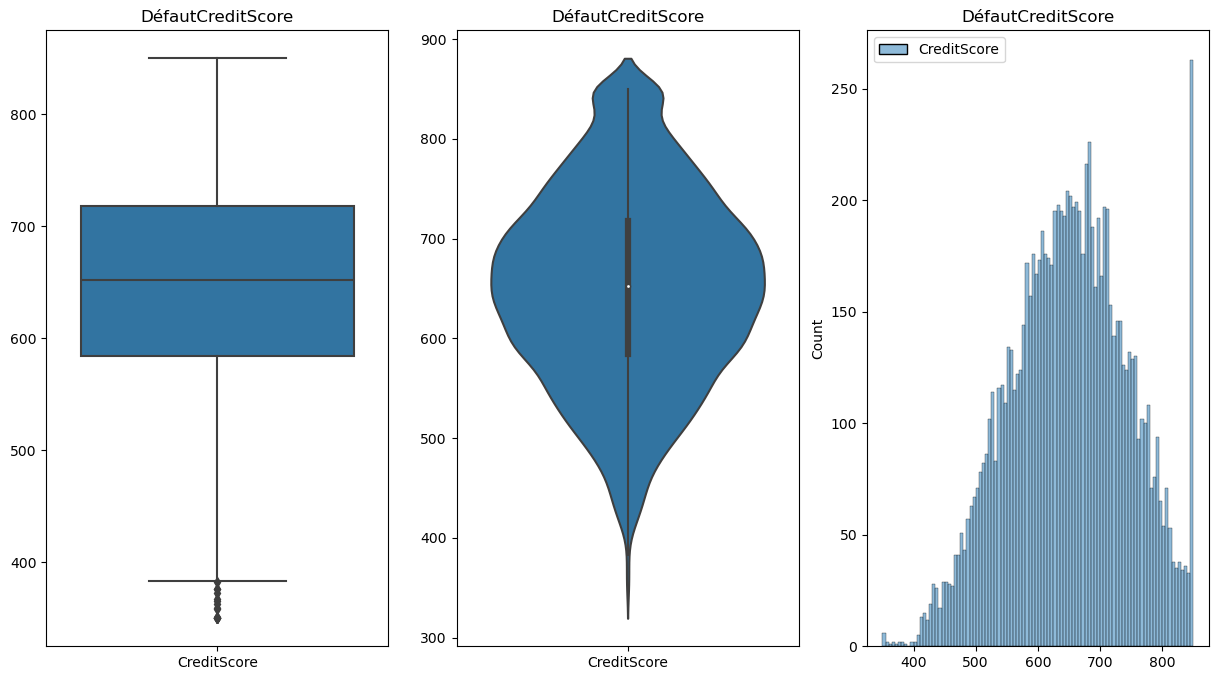

/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


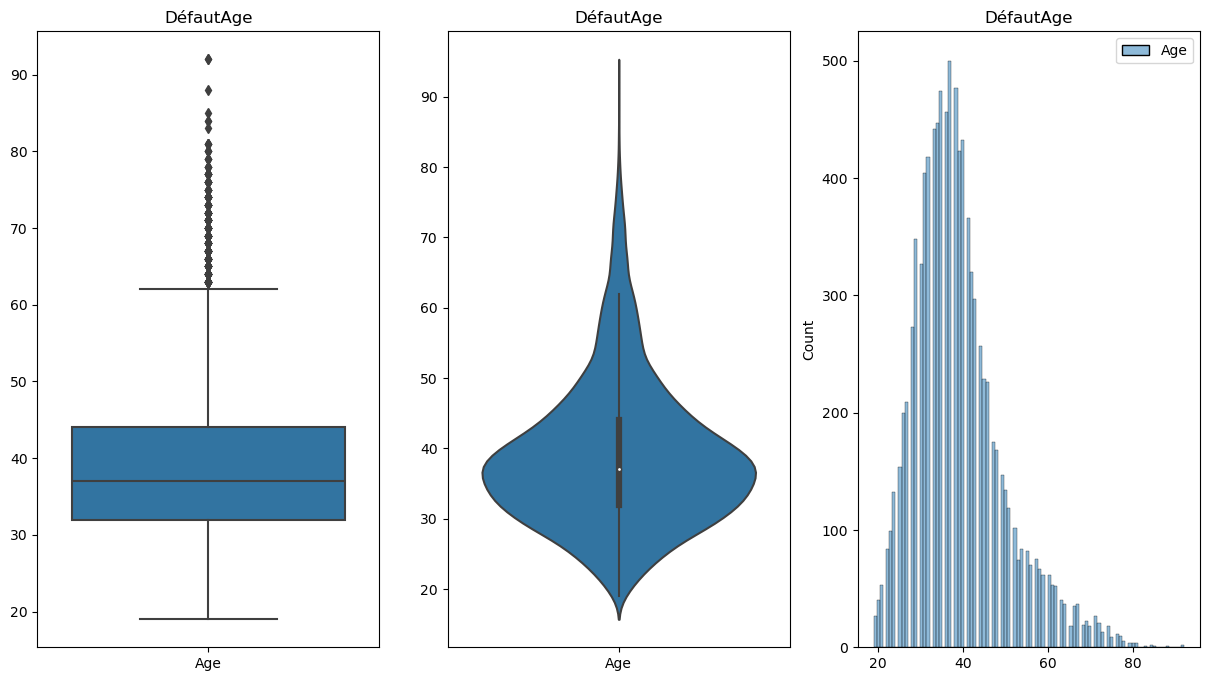

/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


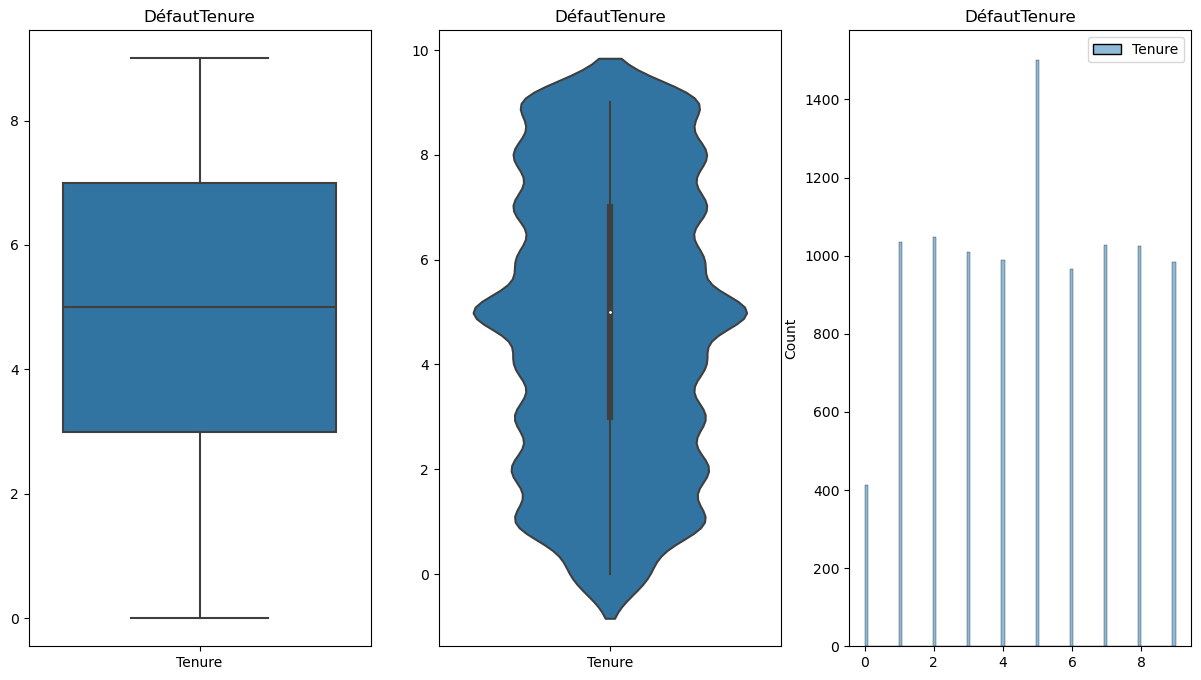

/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


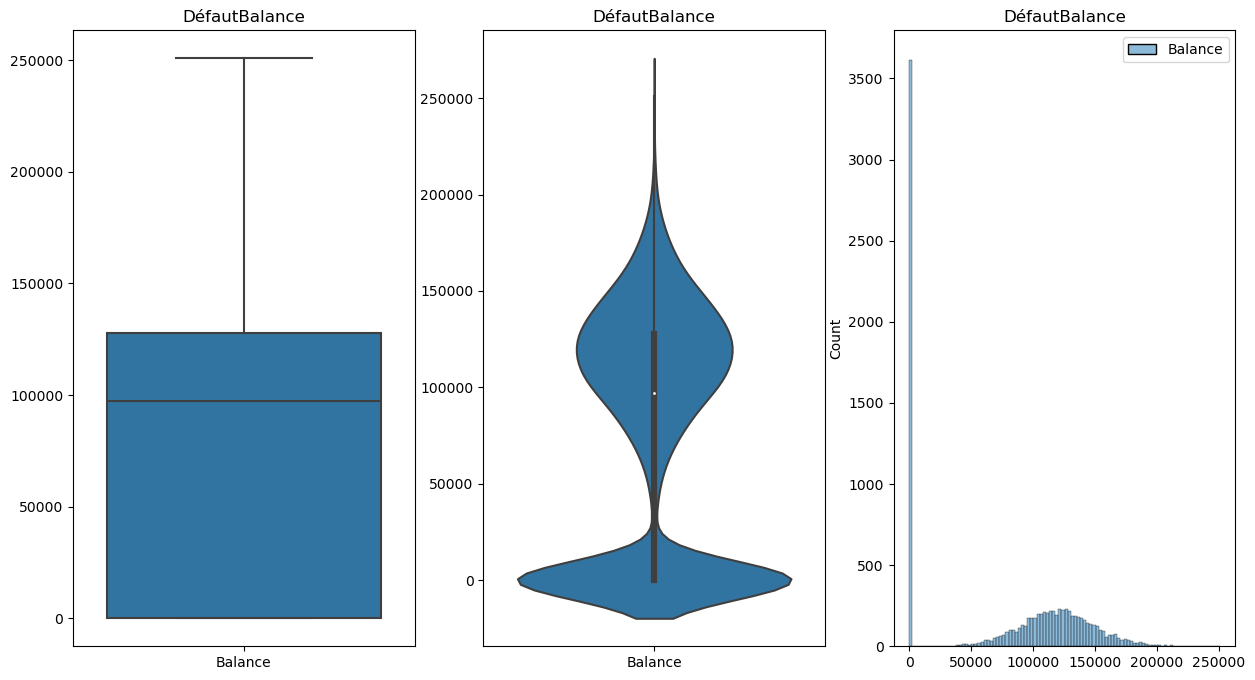

/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


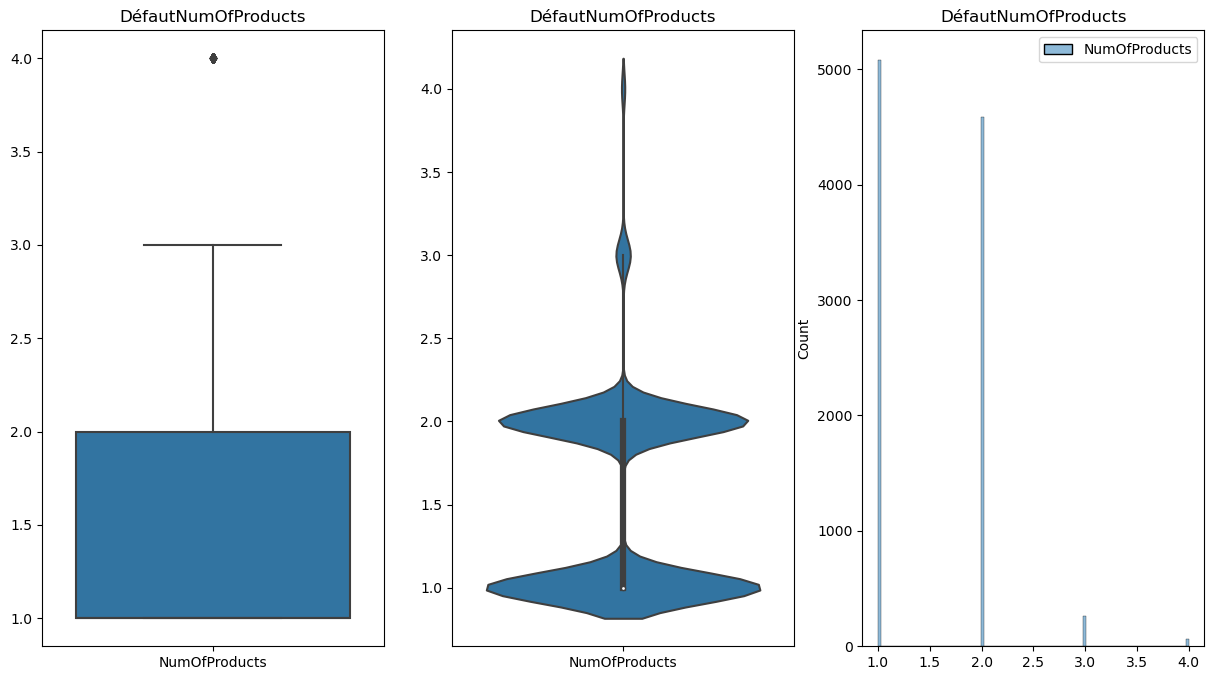

/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


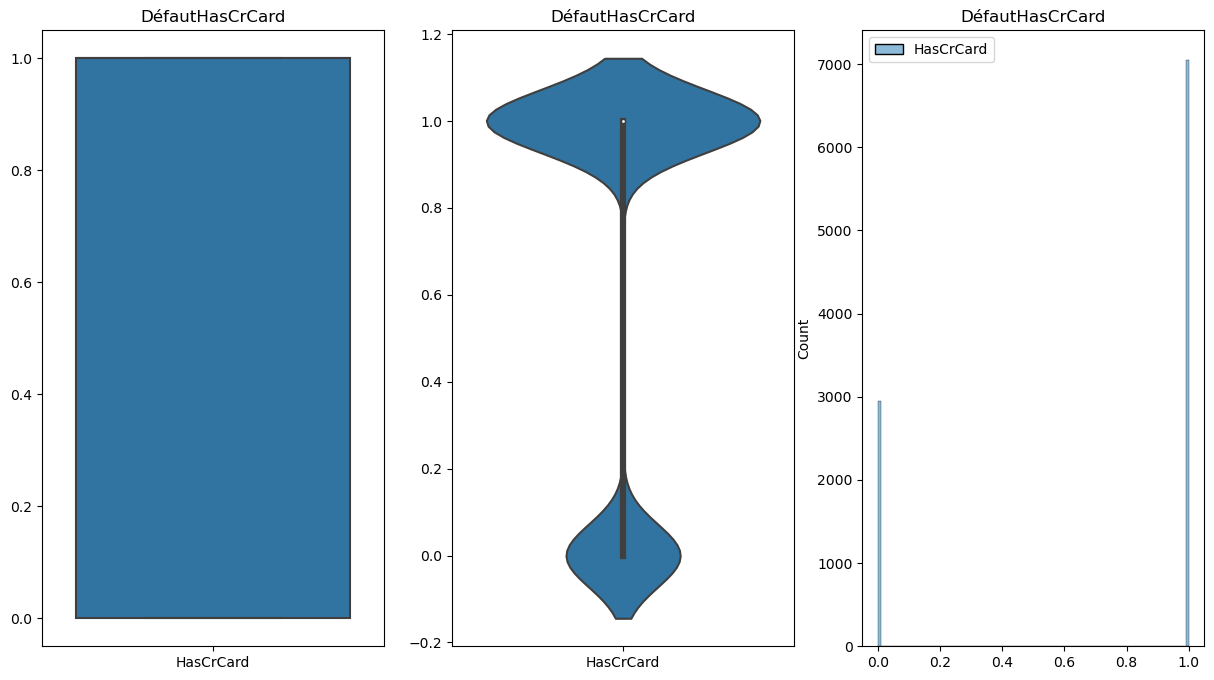

/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


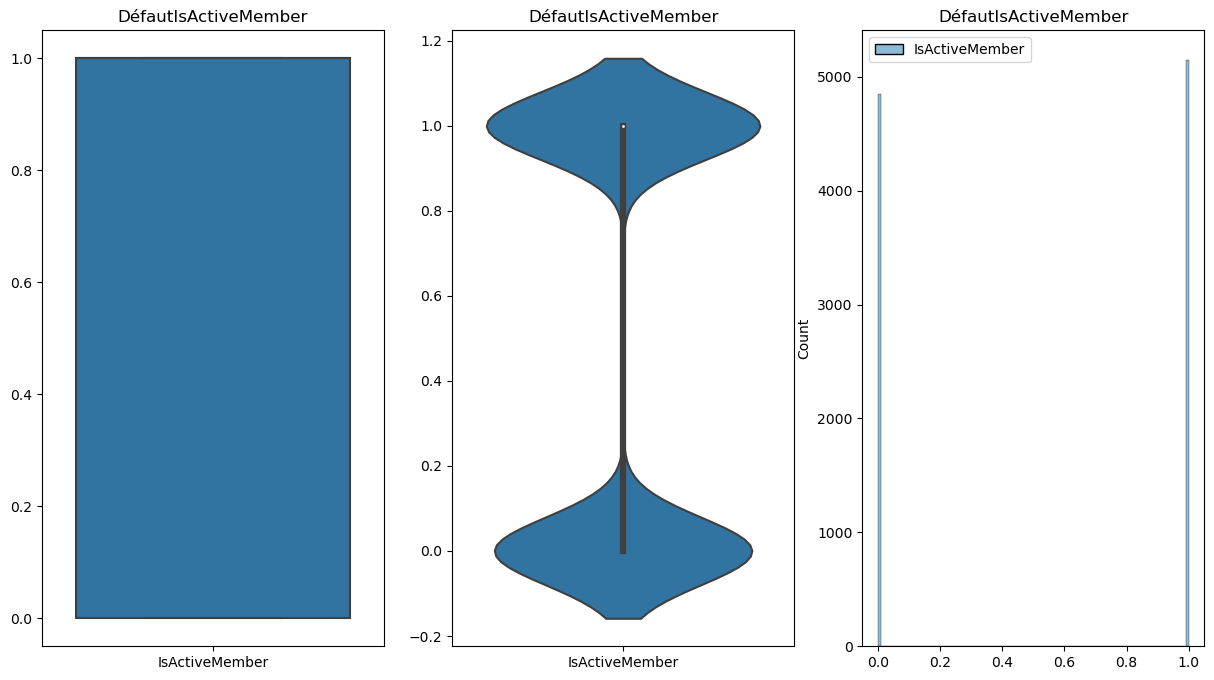

/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


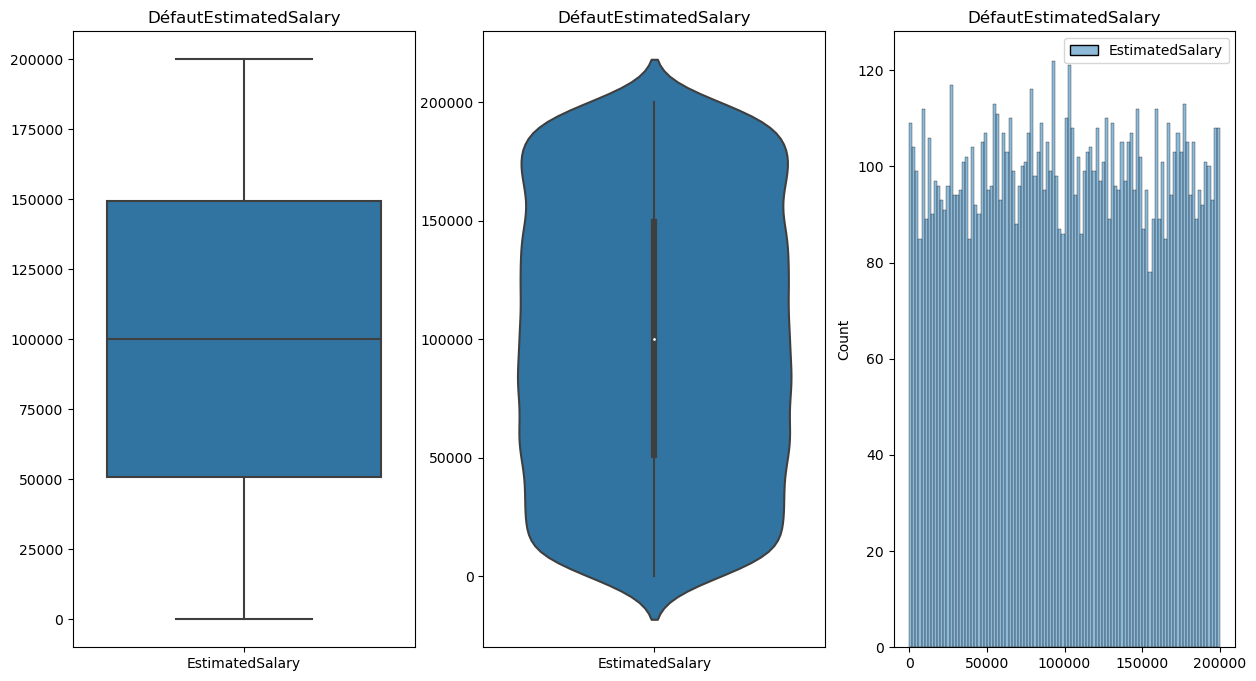

In [16]:
for num_col in num_cols:
    if num_col == 'Exited':
        continue
    plt.figure(figsize=(15,8))
    j=1
    plt.subplot(1, 3, j)
    sns.boxplot(df[[num_col]])
    plt.title('Défaut' + str(num_col))
    j+=1
    plt.subplot(1, 3, j)
    sns.violinplot(df[[num_col]])
    plt.title('Défaut' + str(num_col))
    j+=1
    plt.subplot(1, 3, j)
    sns.histplot(df[[num_col]],bins=100)
    plt.title('Défaut' + str(num_col))      
    plt.show()
    

## details distribution de variables numériques

In [17]:
df["Age"].describe([0.01, 0.25, 0.5, 0.75, 0.99])

count    9999.000000
mean       38.963096
std        10.441769
min        19.000000
1%         21.000000
25%        32.000000
50%        37.000000
75%        44.000000
99%        72.000000
max        92.000000
Name: Age, dtype: float64

/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


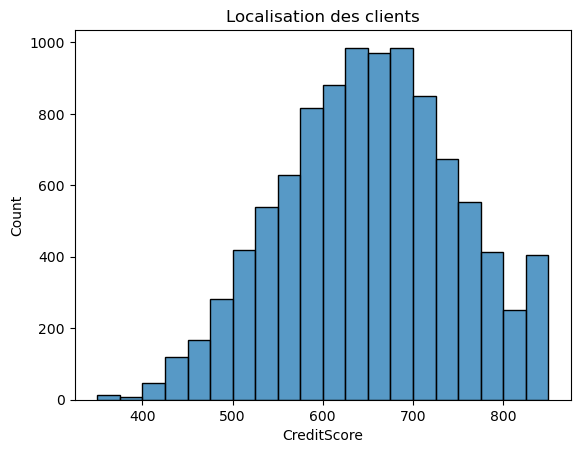

In [19]:
## Histogramme d'une variable numerique 

sns.histplot(x = "CreditScore", data = df, bins = 20)
plt.title("Localisation des clients", fontsize = 12);

/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


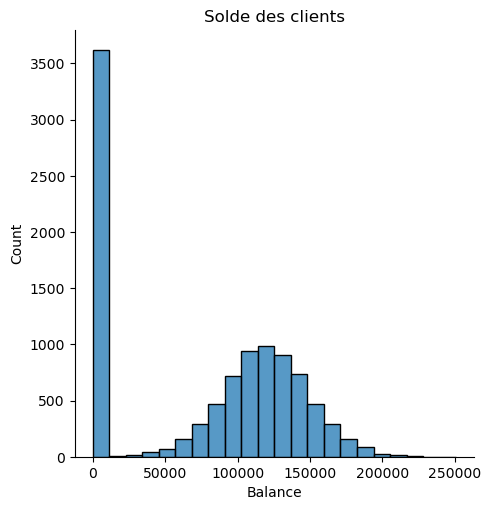

In [20]:
# Displot si continu
sns.displot(x = "Balance", data = df)
plt.title("Solde des clients", fontsize = 12);

In [122]:
# Un seul outlier
#un colonne à transformer en catégorielles

from imblearn.over_sampling import SMOTE 
from sklearn.preprocessing import LabelEncoder

,df,sum_sq,mean_sq,F,PR(>F)
Age,1.0,132.146531,132.146531,887.050612,7.888711e-187
Residual,9997.0,1489.282412,0.148973,NaN,NaN


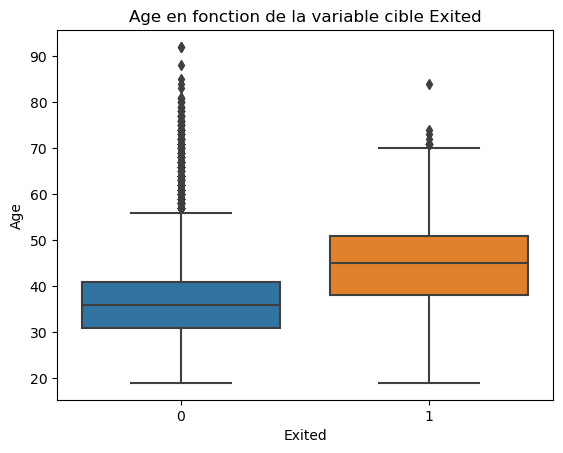

In [23]:
import statsmodels.api

#Réalisation d'un test statistique ANOVA avec p value! (variable catégorielle vs variavle con)

result = statsmodels.formula.api.ols('Exited ~ Age', data=df).fit()
table = statsmodels.api.stats.anova_lm(result)
display(table)

sns.boxplot(x = "Exited", y = "Age", data = df)
plt.title("Age en fonction de la variable cible Exited");

2.770061773262406e-26


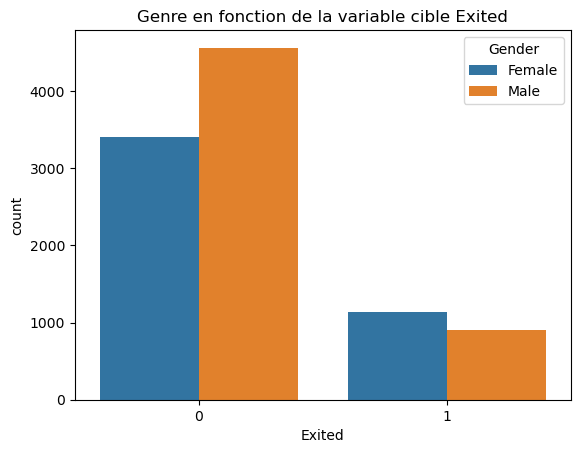

In [27]:
#Réalisation d'un test statistique chi2 avec 2 variables catégorielles
from scipy.stats import chi2_contingency
 
ct = pd.crosstab(df['Exited'], df['Gender'])
print(chi2_contingency(ct)[1])

sns.countplot(x = "Exited", hue = "Gender", data = df)
plt.title("Genre en fonction de la variable cible Exited");

# Remise au propre

In [153]:
from scipy.stats import chi2_contingencyMember'].astype('object')

#imputation des valeurs manquantes
df['Age']= mean_imputation(df=df,column='Age')
df['Tenure']= mode_imputation(df=df,column='Tenure')
#df['Tenure']=df['Tenure'].astype('object')

df=df.loc[df['Age']<72]

print(type(df.Tenure),end="\n\n")

#suppression de la colonne Surname
df_copy=df.copy()
df_copy=df_copy.drop(['Surname'],axis=1)
print("colonne Surname supprimée")

#suppression des doublons
df_cleaned=drop_duplicates(df_copy)

#séparation variables cible
data = df_cleaned.iloc[:,:-1]
target = df_cleaned.iloc[:,-1:]

#Détermination des colonnes cathegorielles et numériques
cat_cols, num_cols=tri_colonnes(df=data)

# Encodage One-Hot des variables catégorielles
one_hot_enc = pd.get_dummies(data, columns=['Geography', 'Gender','HasCrCard','IsActiveMember'])
# Concaténer les colonnes encodées avec les autres colonnes du DataFrame
encoded_df = pd.concat([data, one_hot_enc], axis=1)
# Supprimer les colonnes d'origine
encoded_df = encoded_df.drop(['Geography', 'Gender','HasCrCard','IsActiveMember'], axis=1)

# Créer un LabelEncoder poru la variable Temure
#le = LabelEncoder()
#encoded_df['Tenure'] = le.fit_transform(encoded_df['Tenure'])

print(encoded_df.columns,end="\n\n")
print(num_cols,end="\n\n")

#Séparation des données
X_train,X_test,y_train,y_test=split_data(encoded_df,target,test_size=0.2)       

# Standardisation     
X_train[num_cols],X_test[num_cols],preprocessing_step= standardize_data(X_train[num_cols],X_test[num_cols])


Data loaded successfully from /media/frederic/Echanges_Linux_Windows/GitHUb/Technical_Day_DS_2024/data_to_use/raw/bankchurn.csv
Les valeurs manquantes de la colonne Age ont ete remplacees par la moyenne
Les valeurs manquantes de la colonne Tenure ont ete remplacees par le mode
<class 'pandas.core.series.Series'>

colonne Surname supprimée
Doublons supprimés
Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'EstimatedSalary', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'EstimatedSalary', 'Geography_France',
       'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male',
       'HasCrCard_0', 'HasCrCard_1', 'IsActiveMember_0', 'IsActiveMember_1'],
      dtype='object')

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

Séparation des données effectuée:
Shape X_train : (7915, 21)
Shape X_test : (1979, 21)
Shape y_train : (7915, 1)
Shape y_test : (1979, 1)
Standardisation effectuée des variables nu

In [154]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,CreditScore,Age,Tenure,Balance,...,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,HasCrCard_0,HasCrCard_1,IsActiveMember_0,IsActiveMember_1
CustomerId,,,,,,,,,,,,,,,,,,,,,
15656717,0.369954,-0.880824,0.510408,-1.225819,0.812285,1.370637,0.369954,-0.880824,0.510408,-1.225819,...,1.370637,True,False,False,True,False,True,False,True,False
15790314,-0.022864,0.245574,-1.696173,-1.225819,0.812285,0.527809,-0.022864,0.245574,-1.696173,-1.225819,...,0.527809,True,False,False,False,True,True,False,False,True
15658768,-1.077267,1.064772,-0.960646,-1.225819,-0.909986,-0.600240,-1.077267,1.064772,-0.960646,-1.225819,...,-0.600240,True,False,False,True,False,True,False,True,False
15729689,1.062552,-0.368825,0.510408,0.351702,0.812285,0.104139,1.062552,-0.368825,0.510408,0.351702,...,0.104139,False,True,False,False,True,True,False,False,True
15756743,-0.270959,-0.164026,0.878172,0.628679,-0.909986,-0.894479,-0.270959,-0.164026,0.878172,0.628679,...,-0.894479,True,False,False,True,False,False,True,True,False


In [155]:
# test du modèle LR
clf = LogisticRegression(random_state=0,max_iter=1000).fit(X_smote, y_smote)

# Entraîner le modèle sur les données d'entraînement
clf.fit(X_train, y_train)

# Prédire les étiquettes des données de test
y_pred = clf.predict(X_test)

# Calculer le F1 score global pour des données binaires
f1 = f1_score(y_test, y_pred, average='binary')

# Afficher le F1 score
print(f1)


/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.32798573975044565


In [156]:
# Créer un modèle de Random Forest
rf = RandomForestClassifier(random_state=0)

# Entraîner le modèle sur les données d'entraînement
rf.fit(X_train, y_train)

# Prédire les étiquettes des données de test
y_pred = rf.predict(X_test)

# Calculer le F1 score global pour des données binaires
f1 = f1_score(y_test, y_pred, average='binary')

# Afficher le F1 score
print(f1)


/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.5688622754491018


## Avec SMOTE

In [157]:
#smote = SMOTE(random_state = 42) 
X_smote, y_smote = smote.fit_resample(X_train,y_train)


# test du modèle LR
clf = LogisticRegression(random_state=0,max_iter=1000).fit(X_smote, y_smote)
y_pred_smote = clf.predict(X_test)  

from sklearn.metrics import f1_score
# Calculer le F1 score global pour des données binaires
f1 = f1_score(y_test, y_pred_smote, average='binary')
        
print(f1)

0.4753694581280788


/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [158]:

# Créer un modèle de Random Forest
rf = RandomForestClassifier(random_state=0)

# Entraîner le modèle sur les données d'entraînement
rf.fit(X_smote, y_smote)

# Prédire les étiquettes des données de test
y_pred = rf.predict(X_test)

# Calculer le F1 score global pour des données binaires
f1 = f1_score(y_test, y_pred, average='binary')

# Afficher le F1 score
print(f1)


/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.6094750320102432


In [142]:
from imblearn.over_sampling import BorderlineSMOTE

bsmote = BorderlineSMOTE(random_state = 42)
X_bsmote, y_bsmote = bsmote.fit_resample(X_train,y_train)

In [143]:
# Entraîner le modèle sur les données d'entraînement
rf.fit(X_bsmote, y_bsmote)

# Prédire les étiquettes des données de test
y_pred_bs_smote = rf.predict(X_test)

# Calculer le F1 score global pour des données binaires
f1 = f1_score(y_test, y_pred_bs_smote, average='binary')

# Afficher le F1 score
print(f1)



/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.5699481865284974


In [145]:
from sklearn.model_selection import RandomizedSearchCV

# Définir les hyperparamètres à optimiser
param_dist = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [2, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Créer un modèle de Random Forest
rf = RandomForestClassifier(random_state=0)

# Créer un Random Search avec 50 itérations
rscv = RandomizedSearchCV(
    estimator=rf, param_distributions=param_dist, n_iter=50, cv=5, random_state=0)

#smote = SMOTE(random_state = 42) 
X_smote, y_smote = smote.fit_resample(X_train,y_train)

# Entraîner le modèle sur les données d'entraînement
rscv.fit(X_smote, y_smote)

# Afficher les meilleurs hyperparamètres trouvés
print("Meilleurs hyperparamètres :", rscv.best_params_)

# Évaluer le modèle sur les données de test avec les meilleurs hyperparamètres
y_pred_rscv= rscv.predict(X_test)

# Calculer le F1 score global pour des données binaires
f1 = f1_score(y_test, y_pred_rscv, average='binary')

# Afficher le F1 score
print(f1)



/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/frederic/anaconda3/envs/learn_env/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A co

Meilleurs hyperparamètres : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
0.5745554035567716
